В этом блокноте анализируются показатели продаж шоколада (EDA).

Цели:
* Понять структуру набора данных.
* Проанализировать показатели продаж по продуктам.
* Проанализировать показатели продаж продавцов.
* Проанализировать влияние времени года.
* Проанализировать вклад каналов продаж.
* Проанализировать специфики различных стран в качестве рынков сбыта.

# Скачиваем данные

И подключаем библиотеки

In [86]:
import pandas as pd
from numpy import percentile
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [87]:
choco_data = pd.read_csv("/kaggle/input/datasets/arjunmehta1992/chocolate-sales-in-20222023/Chocolate_Sales.csv")

# Обзор набора данных

## Общий обзор

In [90]:
choco_data.shape

(200000, 11)

In [91]:
choco_data.sample(5)

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
84520,ORD-035514,Hazelnut Milk Bar,Japan,Retail,Emily Clarke,2023-11-04,5.94,17.59,89.67,44,677.88
197586,ORD-193064,White Choco Bar,Australia,Retail,Priya Sharma,2023-10-11,14.80,3.35,163.71,186,524.91
57332,ORD-135322,85% Dark Bar,Brazil,Retail,Arjun Mehta,2022-08-03,2.70,3.30,49.61,61,192.25
103328,ORD-085504,Truffle Gift Box,Australia,Wholesale,James Carter,2023-11-28,15.20,2.69,32.72,148,363.68
195353,ORD-096096,70% Dark Bar,Australia,Retail,Lucas Walker,2023-05-15,7.80,2.82,91.48,104,288.97


In [92]:
choco_data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 84.3 MB


Есть отсутствующие поля в
Order_Date, Discount_Pct, Price_per_Box, Marketing_Spend.
Для каждого столбца таких строк около 0.25% от общего количества строк. Даже если множества строк, содержащих NaN, не пересекаются, то суммарно они составят около 1% от общего количества строк. Ниже будет произведено удаление.

Amount записано не числом. Исправим.

In [93]:
choco_data['Amount'] = choco_data['Amount'].str.replace('$', '', regex=False)
choco_data['Amount'] = pd.to_numeric(choco_data['Amount'], errors='coerce')

In [94]:
print('Количество NA в преобразованных Amount:', len(choco_data[choco_data['Amount'].isna() == True]))

Количество NA в преобразованных Amount: 0


In [95]:
choco_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Discount_Pct,199511.0,13.107457,6.374477,0.00,8.30,12.600,17.50,38.300000
Price_per_Box,199543.0,5.911507,4.954976,2.04,2.95,3.280,4.57,21.650000
Marketing_Spend,199539.0,95.450141,66.243760,4.30,52.27,78.850,118.71,798.222443
Boxes_Shipped,200000.0,139.584105,118.665393,-1642.00,67.00,113.000,180.00,3811.000000
Amount,200000.0,512.861975,365.476774,28.81,287.38,417.295,622.52,12138.090000


Аномальные значения min и max у Boxes_Shipped

In [96]:
choco_data.describe(include='O').T

,count,unique,top,freq
Order_ID,200000,200000,ORD-132165,1
Product,200000,12,70% Dark Bar,64800
Country,200000,5,Australia,92594
Channel,200000,3,Retail,116505
Salesperson,200000,25,Arjun Mehta,67589
Order_Date,199563,2000,2023-08-13,317


Сказано, что датасет за два года, а кол-во уникальных дат 2000

In [97]:
print('Количество полностью дублированных строк:', choco_data.duplicated().sum())
print('Количество дубликатов Order_ID:', choco_data.duplicated('Order_ID').sum())

Количество полностью дублированных строк: 0
Количество дубликатов Order_ID: 0


## Удалим строки, содержащие NaN


In [98]:
choco_data = choco_data.dropna()

In [99]:
choco_data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 198397 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         198397 non-null  object 
 1   Product          198397 non-null  object 
 2   Country          198397 non-null  object 
 3   Channel          198397 non-null  object 
 4   Salesperson      198397 non-null  object 
 5   Order_Date       198397 non-null  object 
 6   Discount_Pct     198397 non-null  float64
 7   Price_per_Box    198397 non-null  float64
 8   Marketing_Spend  198397 non-null  float64
 9   Boxes_Shipped    198397 non-null  int64  
 10  Amount           198397 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 76.3 MB


In [100]:
choco_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Discount_Pct,198397.0,13.106973,6.374328,0.00,8.30,12.60,17.50,38.300000
Price_per_Box,198397.0,5.911864,4.955387,2.04,2.95,3.28,4.57,21.650000
Marketing_Spend,198397.0,95.447343,66.212734,4.30,52.27,78.85,118.72,798.222443
Boxes_Shipped,198397.0,139.575069,118.692310,-1642.00,67.00,113.00,180.00,3811.000000
Amount,198397.0,512.843556,365.307566,28.81,287.35,417.33,622.68,12138.090000


In [101]:
choco_data.describe(include='O').T

,count,unique,top,freq
Order_ID,198397,198397,ORD-061616,1
Product,198397,12,70% Dark Bar,64300
Country,198397,5,Australia,91846
Channel,198397,3,Retail,115566
Salesperson,198397,25,Arjun Mehta,67031
Order_Date,198397,1998,2023-08-13,314


## Преобразуем даты в Order_Date

In [102]:
choco_data['Order_Date'].value_counts().sample(5)

,count
Order_Date,
2023-11-17,262
06-14-2023,2
06-23-2022,2
14/11/2023,2
2023-06-25,265


In [103]:
choco_data['Order_Date'] = pd.to_datetime(choco_data['Order_Date'], format='mixed', dayfirst=True)

In [104]:
print('Количество уникальных дат:', len(choco_data['Order_Date'].unique()))
print('Количество NA в преобразованных датах:', len(choco_data[choco_data['Order_Date'].isna() == True]))

Количество уникальных дат: 730
Количество NA в преобразованных датах: 0


## Рассмотрим выбросы в Boxes_Shipped

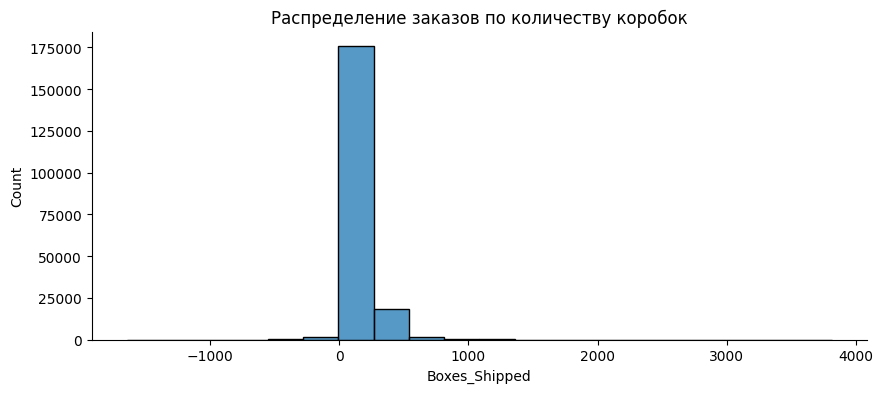

In [105]:
plt.figure(figsize=(10, 4))
sns.histplot(choco_data['Boxes_Shipped'], bins=20)
sns.despine()
plt.title("Распределение заказов по количеству коробок")
plt.show()


In [106]:
choco_data['Boxes_Shipped'].describe().T

,Boxes_Shipped
count,198397.000000
mean,139.575069
std,118.692310
min,-1642.000000
25%,67.000000
50%,113.000000
75%,180.000000
max,3811.000000


In [107]:
print('Количество заказов с отрицательным и нулевым количеством коробок:', len(choco_data.query('Boxes_Shipped <= 0')))

Количество заказов с отрицательным и нулевым количеством коробок: 1938


In [108]:
choco_data = choco_data.query('Boxes_Shipped > 0')

In [109]:
print('99 перцентиль:', percentile(choco_data['Boxes_Shipped'], 99))

99 перцентиль: 559.0


In [110]:
choco_data = choco_data.query('Boxes_Shipped < 560')

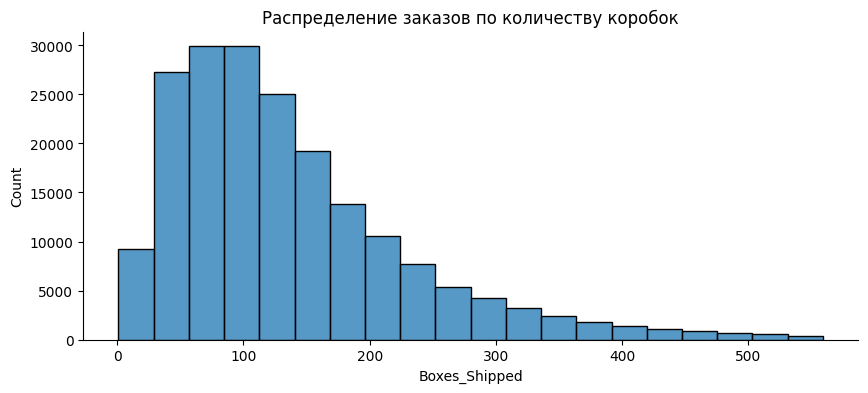

In [111]:
plt.figure(figsize=(10, 4))
sns.histplot(choco_data['Boxes_Shipped'], bins=20)
sns.despine()
plt.title('Распределение заказов по количеству коробок')
plt.show()

In [112]:
choco_data['Boxes_Shipped'].describe().T

,Boxes_Shipped
count,194504.000000
mean,136.144722
std,94.413330
min,1.000000
25%,68.000000
50%,113.000000
75%,178.000000
max,559.000000


25, 50 и 75 перцентили изменились не более, чем на 2 единицы

# Анализ набора данных

In [113]:
choco_data['Rev_After_Marketing'] = choco_data['Amount'] - choco_data['Marketing_Spend']

# ROMI - Return on Marketing Investment
choco_data['ROMI'] = choco_data['Rev_After_Marketing'] / choco_data['Marketing_Spend']

## Анализ показателей продаж по продуктам
И выявление позиций, приносящих наибольшую выручку

<Axes: xlabel='Boxes_Shipped', ylabel='Count'>

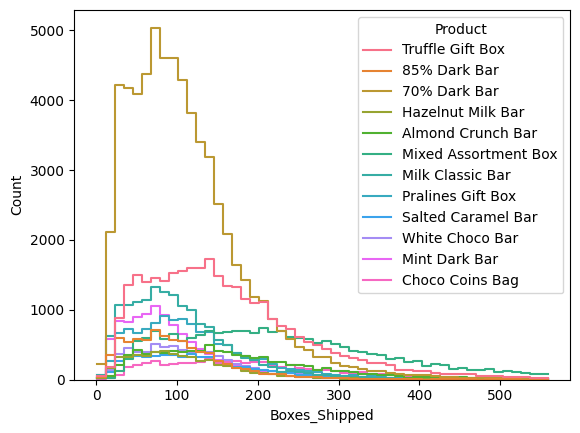

In [114]:
sns.histplot(data=choco_data, x='Boxes_Shipped', hue='Product', bins=50, element='step', fill=False)

Данные не симметричны, используем медиану

In [115]:
agg_Product = choco_data.groupby('Product').agg(
    median_Price_per_Box=('Price_per_Box', 'median'),
    median_Boxes_Shipped=('Boxes_Shipped', 'median'),
    median_Amount=('Amount', 'median'),
    median_ROMI=('ROMI', 'median'),
    sum_Boxes_Shipped=('Boxes_Shipped', 'sum'),
    sum_Amount=('Amount', 'sum'),
    sum_Rev_After_Marketing=('Rev_After_Marketing', 'sum')
).sort_values(
    by=['sum_Amount'],
    ascending=False
).reset_index()

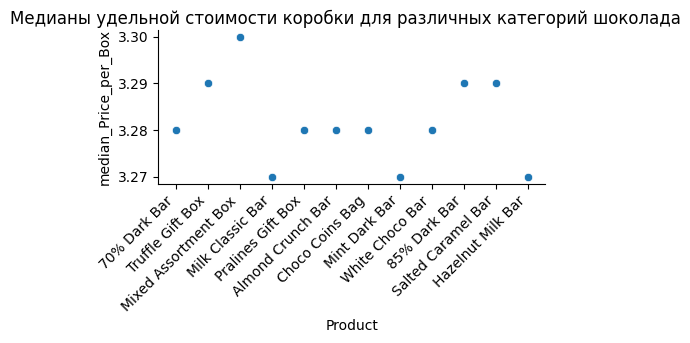

In [116]:
plt.figure(figsize=(5, 2))
sns.scatterplot(data=agg_Product, x='Product', y='median_Price_per_Box')

plt.xticks(rotation=45, ha='right')
plt.suptitle('Медианы удельной стоимости коробки для различных категорий шоколада')
sns.despine()
plt.show()

Цена за коробку для всех категорий примерно одинакова. Максимальная разница около 1%

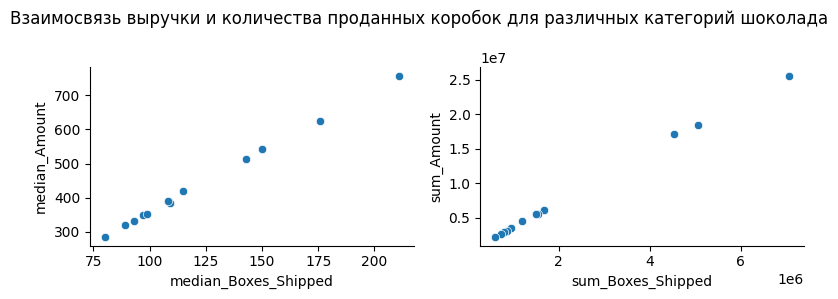

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.scatterplot(ax=axes[0],data=agg_Product, x='median_Boxes_Shipped', y='median_Amount')
sns.scatterplot(ax=axes[1],data=agg_Product, x='sum_Boxes_Shipped', y='sum_Amount')

plt.suptitle('Взаимосвязь выручки и количества проданных коробок для различных категорий шоколада')
sns.despine()
plt.tight_layout()
plt.show()

Наблюдается прямая зависимость выручки от количества коробок, достаточно рассмотреть один параметр, например, только выручку.


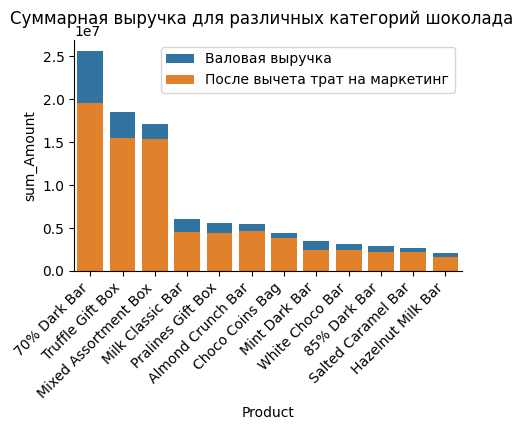

In [118]:
plt.figure(figsize=(5, 3))
sns.barplot(agg_Product, x='Product', y='sum_Amount', label='Валовая выручка')
sns.barplot(agg_Product, x='Product', y='sum_Rev_After_Marketing', label='После вычета трат на маркетинг')

plt.xticks(rotation=45, ha='right')
plt.suptitle('Суммарная выручка для различных категорий шоколада')
sns.despine()
plt.show()

Учет трат на маркетинг не изменил топ-3 продукта по выручке.

In [119]:
print('Топ-3 продуктов по выручке:', *agg_Product['Product'].head(3), sep='\n')

Топ-3 продуктов по выручке:
70% Dark Bar
Truffle Gift Box
Mixed Assortment Box


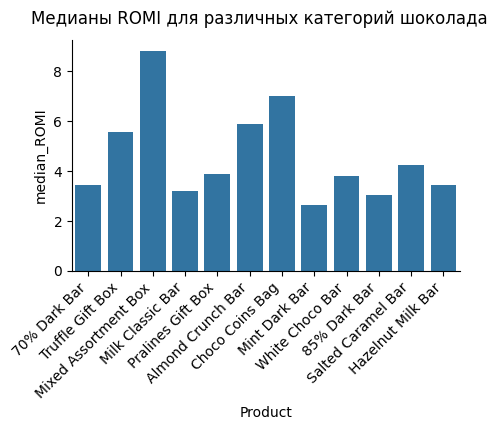

In [120]:
plt.figure(figsize=(5, 3))
sns.barplot(agg_Product, x='Product', y='median_ROMI')

plt.xticks(rotation=45, ha='right')
plt.suptitle('Медианы ROMI для различных категорий шоколада')
sns.despine()
plt.show()

Продукт Mixed Assortment Box окупает инвестиции в маркетинг эффективнее всего.

Продукты Choco Coins Bag и Almond Crunch Bar являются перспективным с точки зрения вложений в маркетинг.

## Анализ показателей продаж продавцов
И выявление продавцов, сотрудничество с которыми приносит наибольшую выручку

In [121]:
agg_Salesperson = choco_data.groupby('Salesperson').agg(
    median_Price_per_Box=('Price_per_Box', 'median'),
    median_Boxes_Shipped=('Boxes_Shipped', 'median'),
    median_Amount=('Amount', 'median'),
    median_ROMI=('ROMI', 'median'),
    sum_Boxes_Shipped=('Boxes_Shipped', 'sum'),
    sum_Amount=('Amount', 'sum'),
    sum_Rev_After_Marketing=('Rev_After_Marketing', 'sum')
).sort_values(
    by=['sum_Amount'],
    ascending=False
).reset_index()

In [122]:
agg_Salesperson.describe().T

,count,mean,std,min,25%,50%,75%,max
median_Price_per_Box,25.0,3.284400e+00,1.044031e-02,3.250000,3.280000,3.280000e+00,3.290000e+00,3.300000e+00
median_Boxes_Shipped,25.0,1.139600e+02,1.767295e+00,112.000000,113.000000,1.130000e+02,1.150000e+02,1.190000e+02
median_Amount,25.0,4.149262e+02,6.511527e+00,394.925000,412.890000,4.145400e+02,4.173100e+02,4.268150e+02
median_ROMI,25.0,4.279541e+00,5.778115e-02,4.164533,4.242695,4.276998e+00,4.314131e+00,4.403726e+00
sum_Boxes_Shipped,25.0,1.059228e+06,1.842840e+06,184284.000000,266712.000000,4.125660e+05,8.702170e+05,8.946194e+06
sum_Amount,25.0,3.879337e+06,6.756163e+06,684796.870000,958182.800000,1.522453e+06,3.169585e+06,3.282195e+07
sum_Rev_After_Marketing,25.0,3.143124e+06,5.472848e+06,557052.393117,774317.868573,1.236263e+06,2.568308e+06,2.659397e+07


Медианы цены за одну коробку, количества коробок в заказе и выручки с заказа для всех продавцов одинаковы

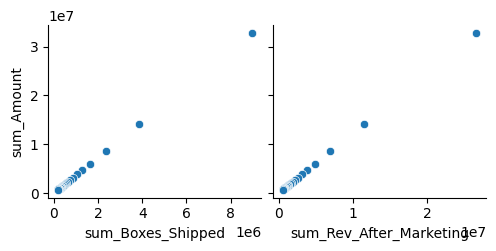

In [123]:
sns.pairplot(data=agg_Salesperson,
    x_vars=['sum_Boxes_Shipped', 'sum_Rev_After_Marketing'],
    y_vars=['sum_Amount'])
plt.show()

Количество проданных коробок, общая выручка и выручка за вычетом маркетинга взаимосвязаны, можно рассматривать только выручку

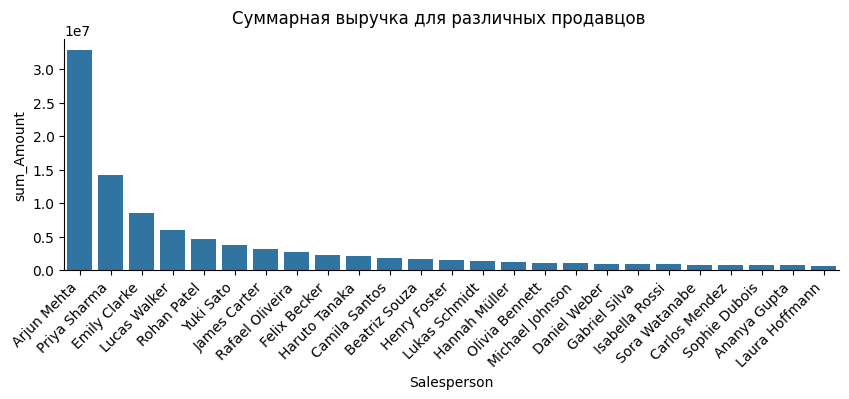

In [124]:
plt.figure(figsize=(10, 3))
sns.barplot(agg_Salesperson, x='Salesperson', y='sum_Amount')

plt.xticks(rotation=45, ha='right')
plt.suptitle('Суммарная выручка для различных продавцов')
sns.despine()
plt.show()

In [125]:
print('Топ-5 продавцов:', *agg_Salesperson['Salesperson'].head(5), sep='\n')

Топ-5 продавцов:
Arjun Mehta
Priya Sharma
Emily Clarke
Lucas Walker
Rohan Patel


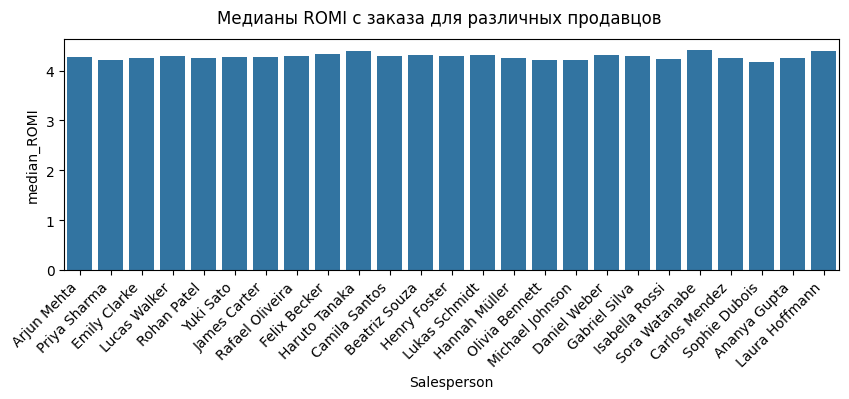

In [126]:
plt.figure(figsize=(10, 3))
sns.barplot(agg_Salesperson, x='Salesperson', y='median_ROMI')

plt.xticks(rotation=45, ha='right')
plt.suptitle('Медианы ROMI с заказа для различных продавцов')
plt.show()

In [127]:
print(f'{(agg_Salesperson['median_ROMI'].max() - agg_Salesperson['median_ROMI'].min()) / agg_Salesperson['median_ROMI'].min() * 100:.1f} %')

5.7 %


Среди продавцов нет явных лидеров с точки зрения окупаемости инвестиций в маркетинг. Разница между максимальным и минимальным значениями менее 6%.

## Анализ влияния времени года на спрос

In [128]:
agg_Order_Date = choco_data.groupby(pd.Grouper(key='Order_Date', freq='W-FRI')).agg(
    median_Price_per_Box=('Price_per_Box', 'median'),
    median_Boxes_Shipped=('Boxes_Shipped', 'median'),
    median_Amount=('Amount', 'median'),
    median_ROMI=('ROMI', 'median'),
    sum_Boxes_Shipped=('Boxes_Shipped', 'sum'),
    sum_Amount=('Amount', 'sum'),
    sum_Rev_After_Marketing=('Rev_After_Marketing', 'sum')
).reset_index()
agg_Order_Date.drop(agg_Order_Date.index[-1], inplace=True)

In [129]:
agg_Order_Date.head()

,Order_Date,median_Price_per_Box,median_Boxes_Shipped,median_Amount,median_ROMI,sum_Boxes_Shipped,sum_Amount,sum_Rev_After_Marketing
0,2022-01-07,3.28,123.0,458.86,4.862168,274079,1029619.97,852832.367194
1,2022-01-14,3.30,125.0,443.55,4.556658,260378,952600.32,782173.986330
2,2022-01-21,3.29,124.0,449.14,4.630463,270648,981882.76,806652.699729
3,2022-01-28,3.30,122.0,448.20,4.605007,269904,1010772.12,831095.640963
4,2022-02-04,3.29,112.0,421.12,4.508619,252411,956526.77,782265.805936


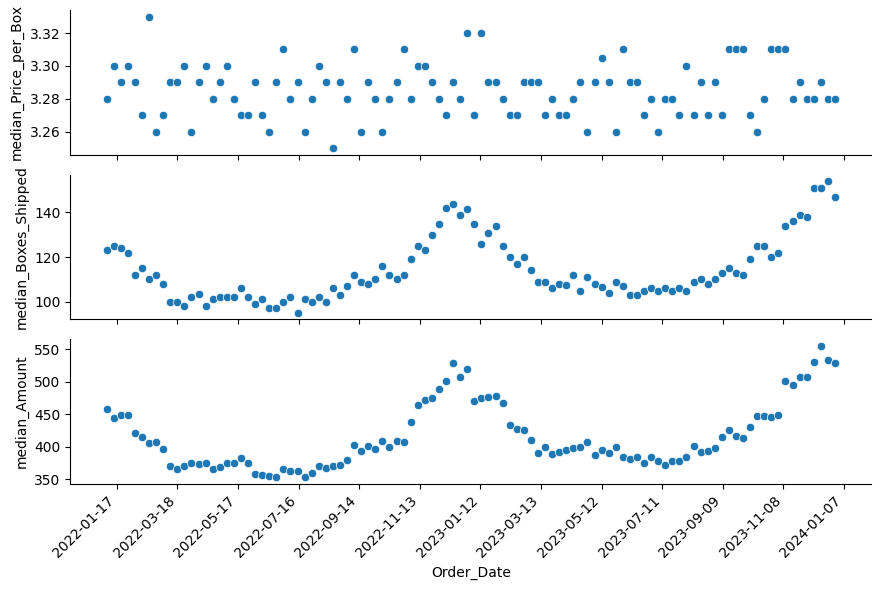

In [130]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

sns.scatterplot(ax=axes[0], data=agg_Order_Date, x='Order_Date', y='median_Price_per_Box')
sns.scatterplot(ax=axes[1], data=agg_Order_Date, x='Order_Date', y='median_Boxes_Shipped')
sns.scatterplot(ax=axes[2], data=agg_Order_Date, x='Order_Date', y='median_Amount')
axes[2].xaxis.set_major_locator(mdates.DayLocator(interval=60))
axes[2].set_xlabel('Order_Date')

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Цена за коробку в заказе постоянна в течение двух лет.

Количество коробок в заказе и выручка за заказ больше в период с ноября по февраль с в связи с возрастающим спросом из-за праздников. В летний период 2023 года наблюдается увеличение выручки за заказ по сравнению с летним периодом 2022 года.

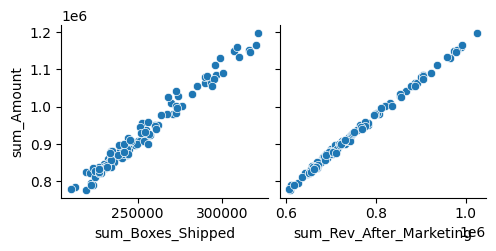

In [131]:
sns.pairplot(data=agg_Order_Date,
    x_vars=['sum_Boxes_Shipped', 'sum_Rev_After_Marketing'],
    y_vars=['sum_Amount'])
plt.show()

Общее количество проданных коробок, общая выручка и общая выручка за вычетом маркетинга взаимосвязаны, можно рассматривать только выручку.

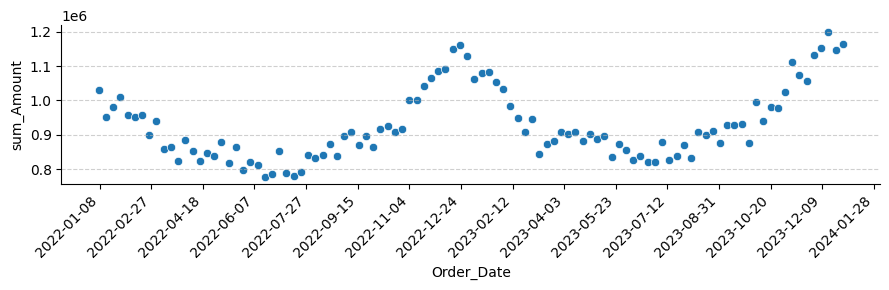

In [132]:
plt.figure(figsize=(9, 3))
sns.scatterplot(data=agg_Order_Date, x='Order_Date', y='sum_Amount')
plt.xlabel('Order_Date')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=18))
sns.despine()
plt.tight_layout()
plt.show()

Сезонность: с ноября по февраль спрос выше.

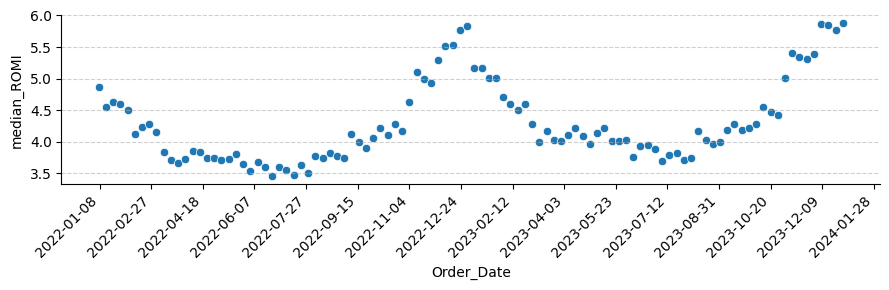

In [133]:
plt.figure(figsize=(9, 3))
sns.scatterplot(data=agg_Order_Date, x='Order_Date', y='median_ROMI')
plt.xlabel('Order_Date')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=18))
sns.despine()
plt.tight_layout()
plt.show()

Окупаемость инвестиций в маркетинг за заказ тоже выше с ноября по февраль.

## Анализ вклада каналов сбыта с учетом времени года

In [134]:
agg_Channel_Order_Date = choco_data.groupby(['Channel', pd.Grouper(key='Order_Date', freq='W-FRI')]).agg(
    median_Price_per_Box=('Price_per_Box', 'median'),
    median_Boxes_Shipped=('Boxes_Shipped', 'median'),
    median_Amount=('Amount', 'median'),
    median_ROMI=('ROMI', 'median'),
    sum_Boxes_Shipped=('Boxes_Shipped', 'sum'),
    sum_Amount=('Amount', 'sum'),
    sum_Rev_After_Marketing=('Rev_After_Marketing', 'sum'),
    count_Order_ID=('Order_ID', 'count')
).reset_index()
agg_Channel_Order_Date.drop(agg_Channel_Order_Date.index[-1], inplace=True)

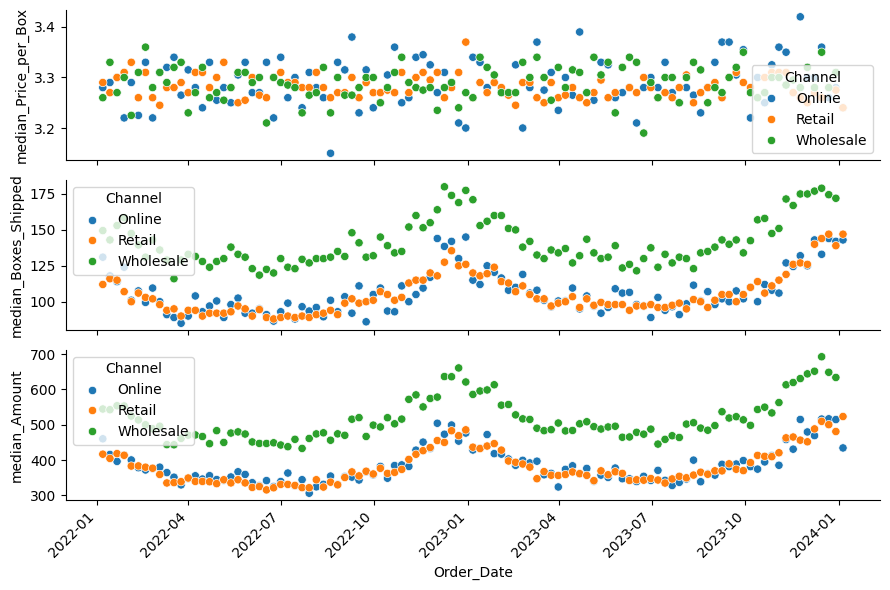

In [135]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
sns.scatterplot(ax=axes[0], x='Order_Date', y='median_Price_per_Box', data=agg_Channel_Order_Date, hue='Channel')
sns.scatterplot(ax=axes[1], x='Order_Date', y='median_Boxes_Shipped', data=agg_Channel_Order_Date, hue='Channel')
sns.scatterplot(ax=axes[2], x='Order_Date', y='median_Amount', data=agg_Channel_Order_Date, hue='Channel')
axes[2].set_xlabel('Order_Date')

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Медианная цена за коробку не зависит от канала продаж и времени.

Медианная выручка с заказа выше у оптовой торговли за счет большего количества коробок в заказе.

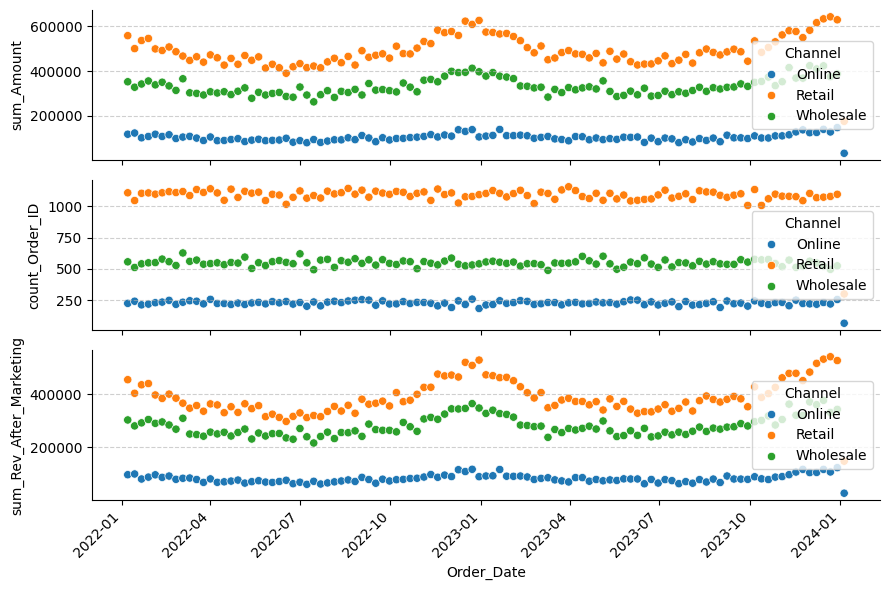

In [136]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

sns.scatterplot(ax=axes[0], x='Order_Date', y='sum_Amount', data=agg_Channel_Order_Date, hue='Channel')
sns.scatterplot(ax=axes[1], x='Order_Date', y='count_Order_ID', data=agg_Channel_Order_Date, hue='Channel')
sns.scatterplot(ax=axes[2], x='Order_Date', y='sum_Rev_After_Marketing', data=agg_Channel_Order_Date, hue='Channel')
axes[-1].set_xlabel('Order_Date')

axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Валовая выручка за неделю в течение всего года выше для розничной торговли по сравнению с остальными каналами продаж даже с учетом вложений в  маркетинг. Преобладание происходит за счет большего количества заказов.

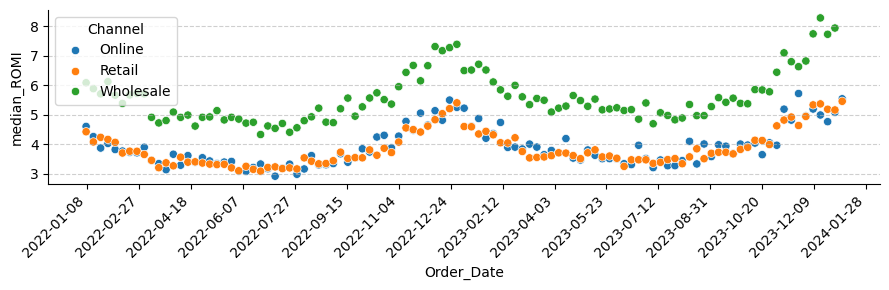

In [137]:
plt.figure(figsize=(9, 3))
sns.scatterplot(data=agg_Channel_Order_Date, x='Order_Date', y='median_ROMI', hue='Channel')
plt.xlabel('Order_Date')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=18))
sns.despine()
plt.tight_layout()
plt.show()

Однако окупаемость инвестиций в маркетинг  в течение всего года выше для оптового канала продаж.

In [138]:
agg_Channel_Order_Date_3 = choco_data.groupby(['Channel']).agg(
    total_Amount=('Amount', 'sum'),
    total_Marketing_Spend=('Marketing_Spend', 'sum'),
    median_ROMI=('ROMI', 'median')
).reset_index()
agg_Channel_Order_Date_3['share_total_Amount'] = (agg_Channel_Order_Date_3['total_Amount'] / agg_Channel_Order_Date_3['total_Amount'].sum()) * 100
agg_Channel_Order_Date_3['share_total_Marketing_Spend'] = (agg_Channel_Order_Date_3['total_Marketing_Spend'] / agg_Channel_Order_Date_3['total_Marketing_Spend'].sum()) * 100

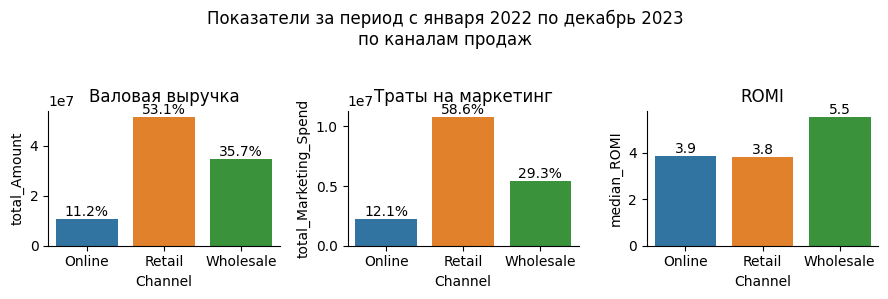

In [139]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True)

num_ax = 0
sns.barplot(ax=axes[num_ax], data=agg_Channel_Order_Date_3, x='Channel', y='total_Amount', hue='Channel')
for i in range(len(axes[num_ax].containers)):
    labels = [f'{agg_Channel_Order_Date_3['share_total_Amount'][i]:0.1f}%']
    axes[num_ax].bar_label(axes[num_ax].containers[i], labels=labels)
axes[num_ax].set_title('Валовая выручка')

num_ax = 1
sns.barplot(ax=axes[num_ax], data=agg_Channel_Order_Date_3, x='Channel', y='total_Marketing_Spend', hue='Channel')
for i in range(len(axes[num_ax].containers)):
    labels = [f'{agg_Channel_Order_Date_3['share_total_Marketing_Spend'][i]:0.1f}%']
    axes[num_ax].bar_label(axes[num_ax].containers[i], labels=labels)
axes[num_ax].set_title('Траты на маркетинг')

num_ax = 2
sns.barplot(ax=axes[num_ax], data=agg_Channel_Order_Date_3, x='Channel', y='median_ROMI', hue='Channel')
for i in range(len(axes[num_ax].containers)):
    labels = [f'{agg_Channel_Order_Date_3['median_ROMI'][i]:0.1f}']
    axes[num_ax].bar_label(axes[num_ax].containers[i], labels=labels)
axes[num_ax].set_title('ROMI')

plt.suptitle('Показатели за период с января 2022 по декабрь 2023\nпо каналам продаж')
sns.despine()
plt.tight_layout()
plt.show()

Половину валовой выручки принес розничный канал продаж. Однако у него самые большие траты на маркетинг. Окупаемость инвестиций в маркетинг выше у оптового канала продаж, и выгоднее масштабировать оптовый канал продаж.

## Анализ специфики различных стран в качестве рынков сбыта

### Анализ спроса на различные товары

In [140]:
agg_Country_Product = choco_data.groupby(['Country', 'Product']).agg(
    sum_Amount=('Amount', 'sum'),
    median_ROMI=('ROMI', 'median')
).sort_values(
    by=['sum_Amount'],
    ascending=False
).reset_index()

In [141]:
tomap_Country_Product = agg_Country_Product.pivot(index='Country', columns='Product', values='sum_Amount')
tomap_Country_Product = tomap_Country_Product.reindex(tomap_Country_Product.sum().sort_values(ascending=False).index, axis=1)

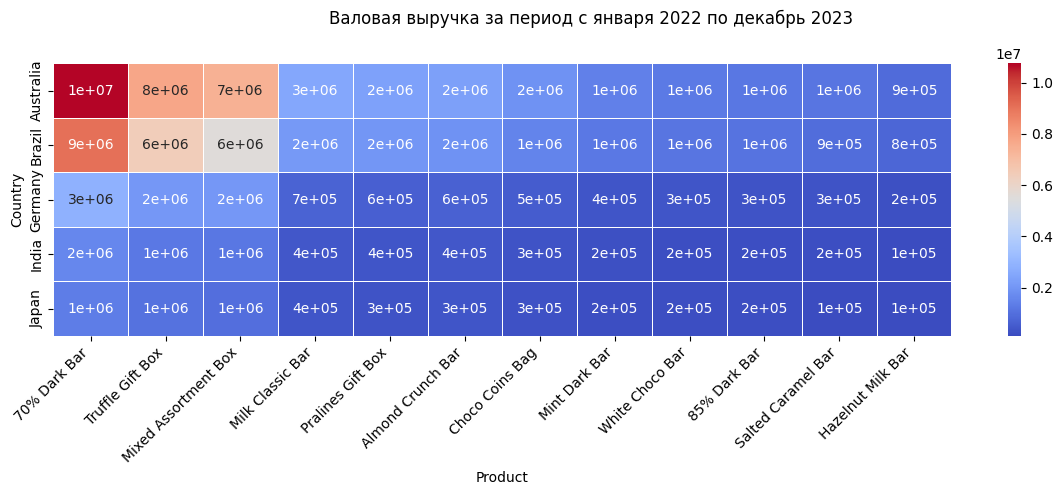

In [142]:
plt.figure(figsize=(12, 5))
sns.heatmap(tomap_Country_Product, annot=True, fmt='.0e', cmap='coolwarm', linewidth=.5)
plt.xticks(rotation=45, ha='right')
plt.suptitle('Валовая выручка за период с января 2022 по декабрь 2023')
plt.tight_layout()
plt.show()

Распределение популярности товаров внутри стран примерно одинаково.

Главная страна-потребитель: Австралия.

In [143]:
tomap_Country_Product_ROMI = agg_Country_Product.pivot(index='Country', columns='Product', values='median_ROMI')
tomap_Country_Product.update(tomap_Country_Product_ROMI)

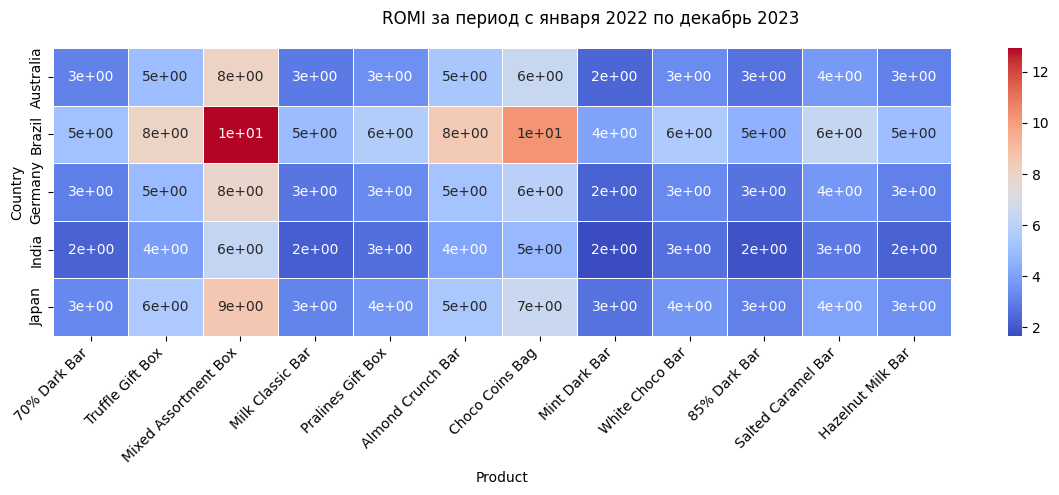

In [144]:
plt.figure(figsize=(12, 5))
sns.heatmap(tomap_Country_Product, annot=True, fmt='.0e', cmap='coolwarm', linewidth=.5)
plt.xticks(rotation=45, ha='right')
plt.suptitle('ROMI за период с января 2022 по декабрь 2023')
plt.tight_layout()
plt.show()


Продукт Mixed Assortment Box окупает инвестиции в маркетинг эффективнее всего во всех странах.

Продукты Choco Coins Bag и Almond Crunch Bar являются перспективным с точки зрения вложений в маркетинг во всех странах.

### Анализ каналов продаж

In [145]:
agg_Country_Channel = choco_data.groupby(['Country', 'Channel']).agg(
    sum_Amount=('Amount', 'sum'),
    median_ROMI=('ROMI', 'median')
).sort_values(
    by=['sum_Amount'],
    ascending=False
).reset_index()

In [146]:
tomap_Country_Channel = agg_Country_Channel.pivot(index='Country', columns='Channel', values='sum_Amount')
tomap_Country_Channel = tomap_Country_Channel.reindex(tomap_Country_Channel.sum().sort_values(ascending=False).index, axis=1)

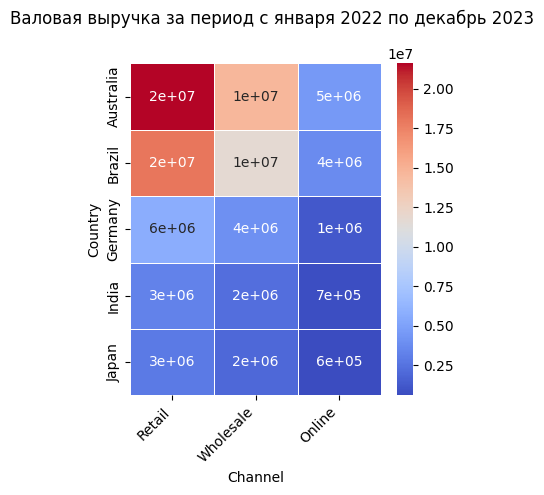

In [147]:
plt.figure(figsize=(4, 5))
sns.heatmap(tomap_Country_Channel, annot=True, fmt='.0e', cmap='coolwarm', linewidth=.5)
plt.xticks(rotation=45, ha='right')
plt.suptitle('Валовая выручка за период с января 2022 по декабрь 2023')
plt.tight_layout()
plt.show()

Распределение каналов по выручке внутри стран примерно одинаково. Везде преобладает розничная продажа.

In [148]:
tomap_Country_Channel_ROMI = agg_Country_Channel.pivot(index='Country', columns='Channel', values='median_ROMI')
tomap_Country_Channel.update(tomap_Country_Channel_ROMI)

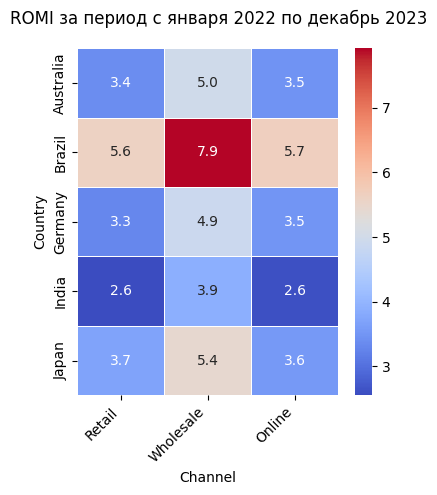

In [149]:
plt.figure(figsize=(4, 5))
sns.heatmap(tomap_Country_Channel, annot=True, fmt='.1f', cmap='coolwarm', linewidth=.5)
plt.xticks(rotation=45, ha='right')
plt.suptitle('ROMI за период с января 2022 по декабрь 2023')
plt.tight_layout()
plt.show()

Окупаемость инвестиций в маркетинг выше для оптового канала продаж во всех странах.

# Выводы

* Наибольшую выручку принесли продукты: 70% Dark Bar,
Truffle Gift Box,
Mixed Assortment Box.
* Продукты Choco Coins Bag и Almond Crunch Bar являются перспективным с точки зрения вложений в маркетинг.
* Наибольшую выручку принесло сотрудничество с продавцами: Arjun Mehta,
Priya Sharma,
Emily Clarke,
Lucas Walker,
Rohan Patel.
* Среди продавцов нет лидеров с точки зрения окупаемости инвестиций в маркетинг
* В период с ноября по февраль наблюдается повышенный спрос на товары.
* Розничный канал обеспечил наибольшую выручку.
* Оптовый канал продаж показал наибольшую окупаемость вложений в маркетинг.
* Австралия приносит наибольшую выручку среди стран.
